# Assignment No: 02

### Rollno. - 33157 DIV-A (TE-CS)
## Data Wrangling - II
**Dataset:** StudentsPerformance_m.csv
**Source:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load Dataset
df = pd.read_csv('StudentsPerformance.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
# Step 1: Check Missing Values
print("Missing Values:")
print(df.isnull().sum())
print("\nTotal:", df.isnull().sum().sum())

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Total: 0


In [ ]:
# Handle Missing Values using Median
df['reading score'].fillna(df['reading score'].median(), inplace=True)
df['writing score'].fillna(df['writing score'].median(), inplace=True)
print("After handling missing values:")
print(df.isnull().sum())

After handling missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [ ]:
# Step 2: Detect Outliers using IQR
numeric_cols = ['math score', 'reading score', 'writing score']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Lower={lower}, Upper={upper}, Outliers={len(outliers)}")

math score: Lower=27.0, Upper=107.0, Outliers=8
reading score: Lower=29.0, Upper=109.0, Outliers=6
writing score: Lower=25.875, Upper=110.875, Outliers=5


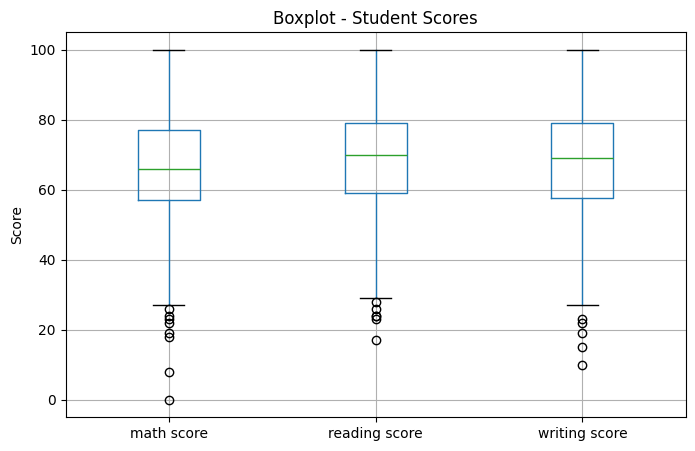

In [ ]:
# Visualize with Boxplot
df[numeric_cols].boxplot(figsize=(8,5))
plt.title('Boxplot - Student Scores')
plt.ylabel('Score')
plt.show()

In [ ]:
# Cap Outliers using IQR (Winsorization)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
print("Outliers capped.")
print(df[numeric_cols].describe())

Outliers capped.
        math score  reading score  writing score
count  1000.000000    1000.000000    1000.000000
mean     66.165000      69.201000      68.094375
std      14.922414      14.503481      15.068368
min      27.000000      29.000000      25.875000
25%      57.000000      59.000000      57.750000
50%      66.000000      70.000000      69.000000
75%      77.000000      79.000000      79.000000
max     100.000000     100.000000     100.000000


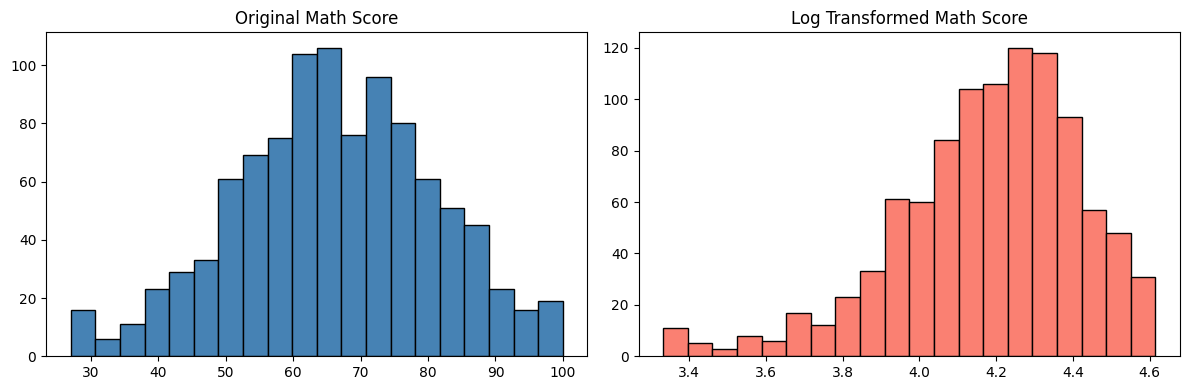

Original Skewness : -0.1488
Log Skewness       : -0.8798


In [ ]:
# Step 3: Data Transformation - Log Transformation on math score
df['math_log'] = np.log1p(df['math score'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['math score'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Original Math Score')

axes[1].hist(df['math_log'], bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Log Transformed Math Score')

plt.tight_layout()
plt.show()

print("Original Skewness :", df['math score'].skew().round(4))
print("Log Skewness       :", df['math_log'].skew().round(4))